## Goal - Predicting Insurance fraud

### **1. Importing necessary packages**

In [892]:
#data reading and manipulation packages
import numpy as np
import pandas as pd

#data visualization packages
import matplotlib.pyplot as plt
import seaborn as sns

#convert object or labeled data into numeric from processing
from sklearn.preprocessing import LabelEncoder

#machine learning related packages
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

### **2. Reading and exploring the data**



In [893]:
df = pd.read_csv('..\data\export.csv')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ritik\AppData\Local\Temp\ipykernel_21580\3037134477.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('..\data\export.csv')


In [894]:
df.shape

(1000, 39)

In [895]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17 00:00:00,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27 00:00:00,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06 00:00:00,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25 00:00:00,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06 00:00:00,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [896]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

# **No of fraud and Non-fraud cases present in the datasets**

In [897]:
df.fraud_reported.value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

## 1. months_as_customer
* Represents how long the customer has been associated with the insurance company, which may influence trust and claim behavior.



## 2. age
* Represents the age of the insured customer, which may affect driving patterns and fraud tendencies.



## 3. policy_bind_date || incident_date || incident_hour_of_the_day
* Time-related features that may reveal suspicious claim timing or unusual incident patterns.



## 4. umbrella_limit
* Represents additional insurance coverage limits that may influence claim size and financial exposure.



## 5. policy_csl
* Represents the policy coverage limit, which can impact the maximum claim payout amount.



## 6. policy_deductible
* Represents the out-of-pocket amount the customer must pay before insurance coverage applies.



## 7. policy_annual_premium
* Represents the yearly premium amount, reflecting policy value and customer risk profile.



## 8. insured_education_level
* Represents the customer's education level, which may indirectly influence financial and claim behavior.



## 9. insured_occupation
* Represents the profession of the customer, which may correlate with lifestyle and risk exposure.



## 10. insured_hobbies
* Represents customer hobbies that may indicate risky activities or accident probability.



## 11. insured_relationship
* Represents the relationship status of the insured customer, which may influence financial responsibilities.



## 12. incident_type
* Represents the category of incident involved in the insurance claim.



## 13. collision_type
* Represents the type of vehicle collision, which may help identify suspicious accident patterns.



## 14. incident_severity
* Represents the seriousness of the incident, which directly impacts claim amount and investigation priority.



## 15. authorities_contacted
* Represents the authority contacted after the incident, improving claim verification reliability.



## 16. witnesses
* Represents the number of witnesses present during the incident, affecting claim credibility.



## 17. police_report_available
* Indicates whether an official police report was filed for the incident.



## 18. total_claim_amount
* Represents the total amount claimed, which is a major indicator in fraud investigation.



## 19. injury_claim
* Represents the amount claimed for bodily injuries related to the incident.



## 20. property_claim
* Represents the amount claimed for property damage caused during the incident.



## 21. vehicle_claim
* Represents the amount claimed for vehicle damage in the accident.



## 22. number_of_vehicles_involved
* Represents the total number of vehicles involved in the incident.



## 23. bodily_injuries
* Represents the number of bodily injuries reported in the incident.



## 24. capital_gains
* Represents profits earned through investments or assets that may reflect customer financial condition.



## 25. capital_loss
* Represents financial losses that may indicate financial stress or risk behavior.



## 26. auto_make || auto_model || auto_year
* Represents vehicle details that may influence repair cost, claim frequency, and fraud risk.



# Target Variable

## fraud_reported
* Represents whether the insurance claim was fraudulent (`Y`) or non-fraudulent (`N`).



**EDA-(Exploratory Data Analysis)** understanding the data to derive the insights from the dataset

In [898]:
df.isnull().sum()

months_as_customer              0
age                             0
policy_number                   0
policy_bind_date                0
policy_state                    0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_zip                     0
insured_sex                     0
insured_education_level         0
insured_occupation              0
insured_hobbies                 0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
witnesses     

In [899]:
(df.authorities_contacted.isnull().sum()/df.shape[0])*100

np.float64(9.1)

In [900]:
df['authorities_contacted'].value_counts()

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Name: count, dtype: int64

In [901]:
df.groupby('incident_severity')['authorities_contacted'].value_counts()

incident_severity  authorities_contacted
Major Damage       Fire                      82
                   Ambulance                 70
                   Other                     66
                   Police                    58
Minor Damage       Police                   111
                   Fire                      76
                   Ambulance                 62
                   Other                     55
Total Loss         Other                     77
                   Police                    74
                   Fire                      65
                   Ambulance                 64
Trivial Damage     Police                    49
Name: count, dtype: int64

In [902]:
# filling out the null values with Other on authorities_contacted category as it has singnificant value on all the categories of incident severity

df['authorities_contacted'].fillna('Other', inplace= True)

C:\Users\ritik\AppData\Local\Temp\ipykernel_21580\1558922490.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['authorities_contacted'].fillna('Other', inplace= True)


In [903]:
#checking if there is stil any null value present

df.isnull().sum().sum()

np.int64(0)

In [904]:
df.duplicated().sum()

np.int64(0)

## **Understanding and Visualizing the datasets**

In [905]:
# check the statistical summary of data
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000


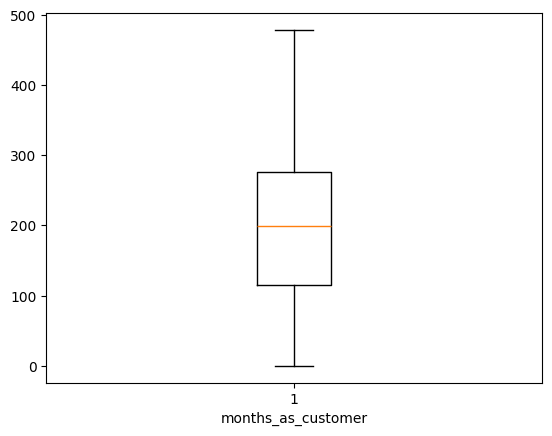

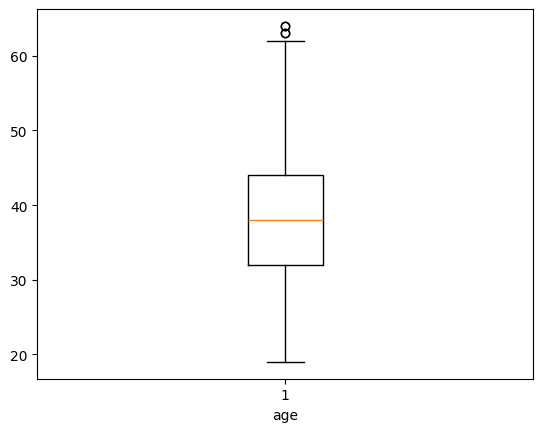

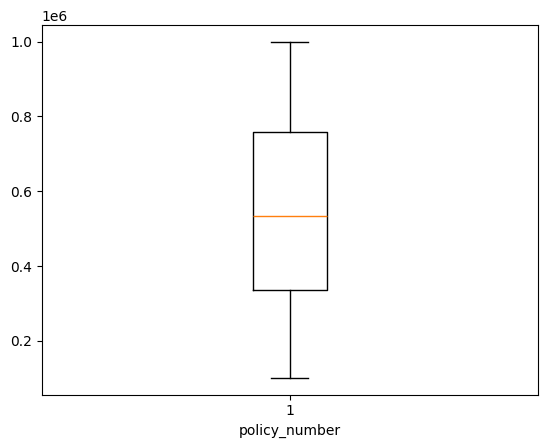

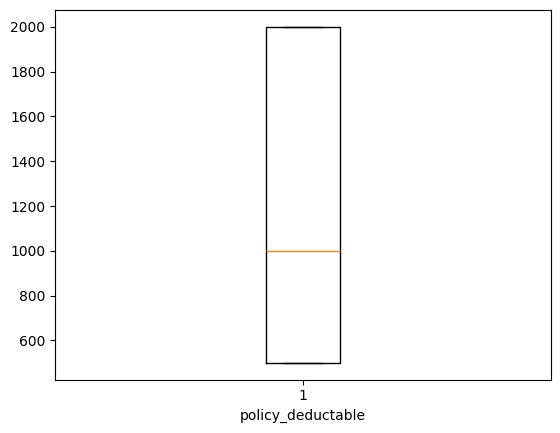

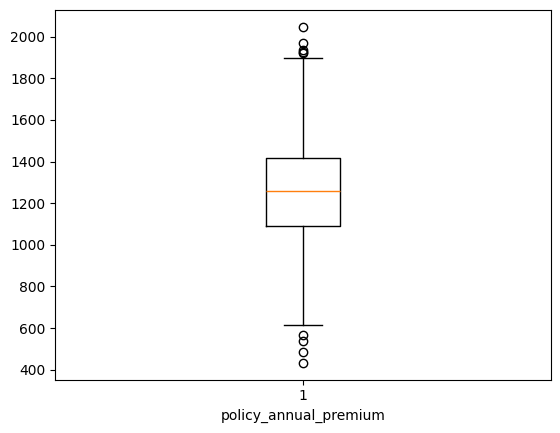

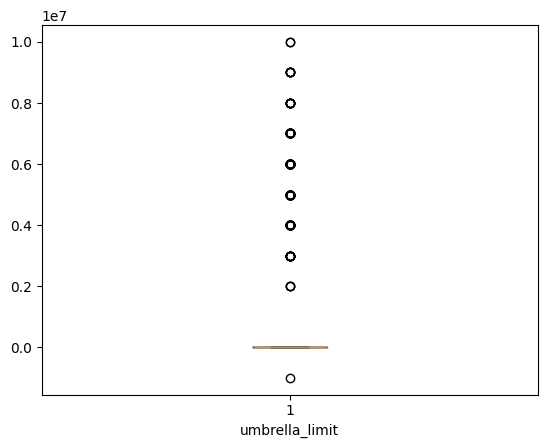

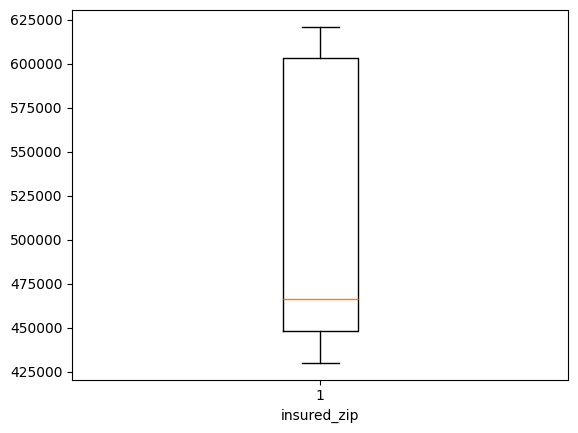

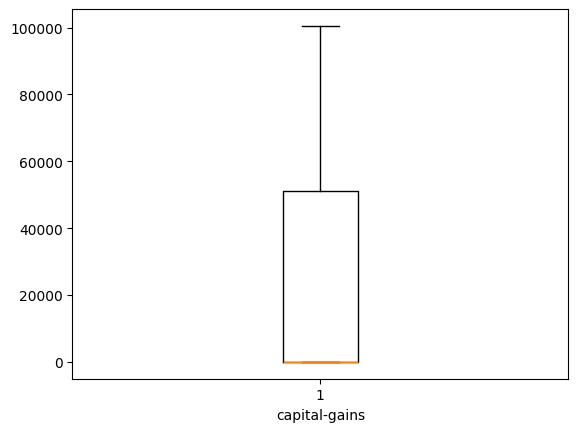

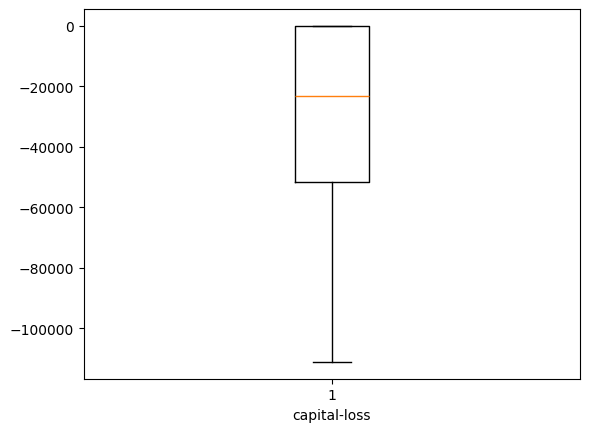

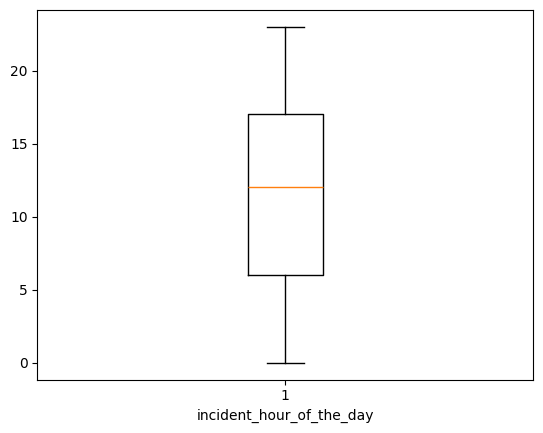

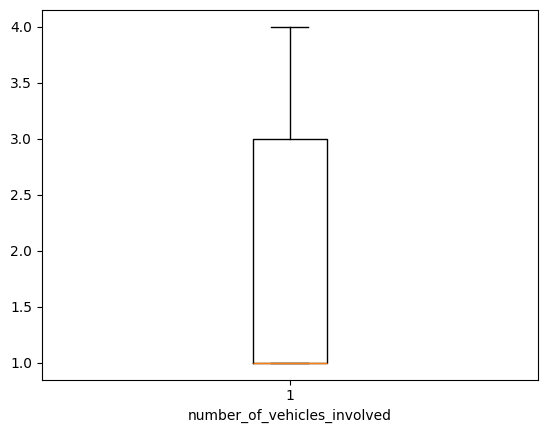

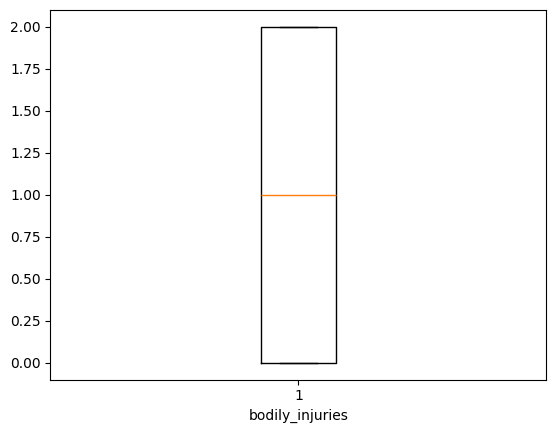

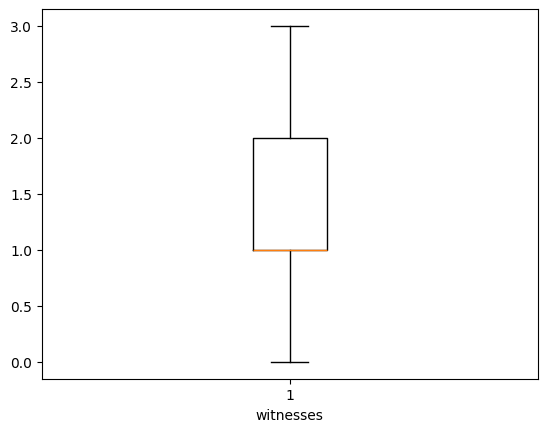

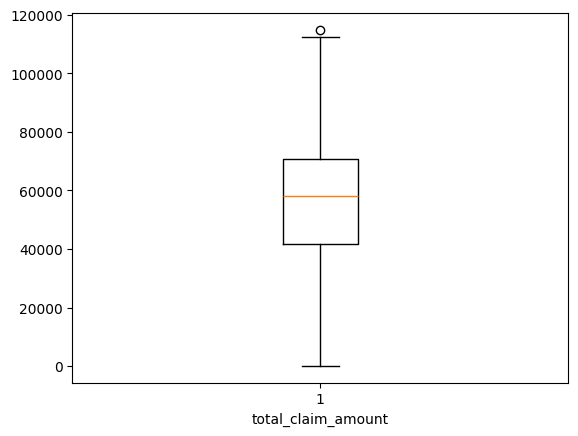

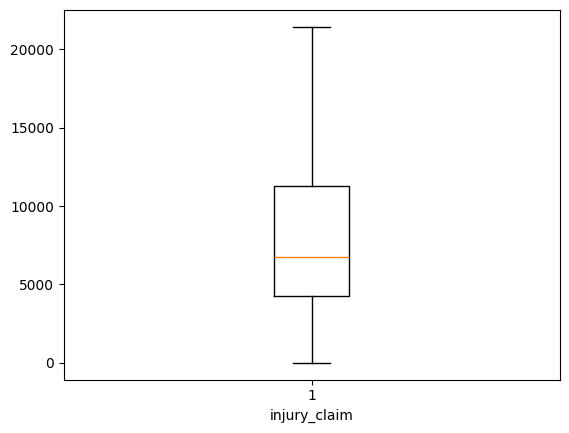

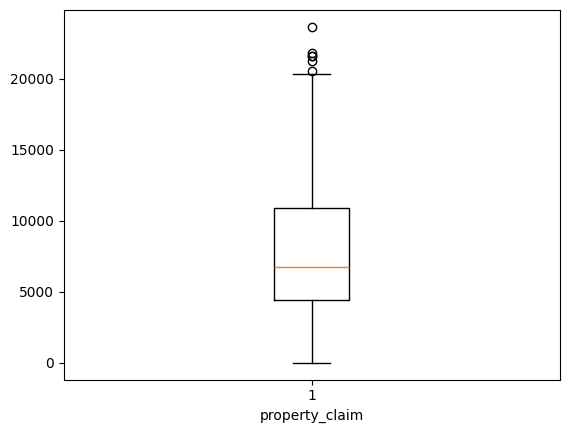

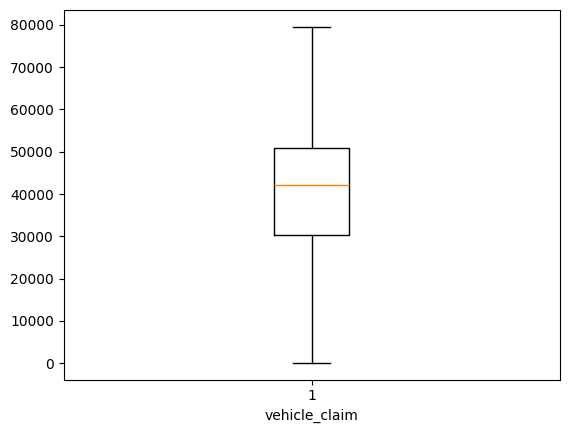

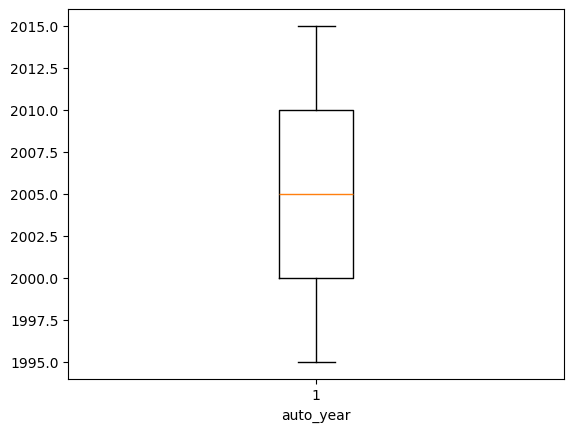

In [906]:
for i in df.columns:
   if df[i].dtype != 'object':
       plt.figure()
       plt.boxplot(df[i])
       plt.xlabel(i)

## **Feature Engineering** 

In [907]:
#fixing the date datatype

df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])

In [908]:
#feature engineering for the policy_csl

# df[['csl_bodily_limit', 'csl_property_limit']] = (df['policy_csl'].str.split('/', expand=True).astype(int))

In [909]:
# extracting insights from dates present

df['policy_duration_days'] = (
     df['incident_date'] - df['policy_bind_date']
).dt.days

In [910]:
#extracting the month

df['incident_month'] = df['incident_date'].dt.month

In [911]:
#extracting the day of the week

df['incident_weekday'] = df['incident_date'].dt.dayofweek

In [912]:
# convert the value of target column from yes/no to 0 and 1

df['fraud_reported']  = np.where(df['fraud_reported'] == 'Y', 1, 0)

In [913]:
df['fraud_reported'].value_counts()

fraud_reported
0    753
1    247
Name: count, dtype: int64

In [914]:
le = LabelEncoder()

In [915]:
#encoding the object type data for the model to process

for i in df.columns:
  if df[i].dtype=='object':
    df[i] = le.fit_transform(df[i])

In [916]:
df.shape

(1000, 42)

***I removed highly correlated claim subcomponents to reduce redundancy since total_claim_amount already captured aggregated claim severity.***

***we also removed the dates and policy_csl as we extracted all the neccessary info from these, so dropping them would be best decesion.***

In [917]:
leakage_columns = ['injury_claim', 'property_claim', 'vehicle_claim']
identifier_columns = ['policy_number']
date_columns = ['incident_date','policy_bind_date','policy_csl']
relative_features = ['incident_location', 'insured_zip','insured_hobbies', 'auto_model']

cols_to_drop =  leakage_columns + identifier_columns + date_columns

df.drop(columns=cols_to_drop, inplace= True)


In [918]:
df.shape

(1000, 35)

In [919]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_state                 1000 non-null   int64  
 3   policy_deductable            1000 non-null   int64  
 4   policy_annual_premium        1000 non-null   float64
 5   umbrella_limit               1000 non-null   int64  
 6   insured_zip                  1000 non-null   int64  
 7   insured_sex                  1000 non-null   int64  
 8   insured_education_level      1000 non-null   int64  
 9   insured_occupation           1000 non-null   int64  
 10  insured_hobbies              1000 non-null   int64  
 11  insured_relationship         1000 non-null   int64  
 12  capital-gains                1000 non-null   int64  
 13  capital-loss       

In [920]:
df

,months_as_customer,age,policy_state,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,...,witnesses,police_report_available,total_claim_amount,auto_make,auto_model,auto_year,fraud_reported,policy_duration_days,incident_month,incident_weekday
0,328,48,2,1000,1406.91,0,466132,1,4,2,...,2,2,71610,10,1,2004,1,100,1,6
1,228,42,1,2000,1197.22,5000000,468176,1,4,6,...,0,0,5070,8,12,2007,1,3130,1,2
2,134,29,2,2000,1413.14,5000000,430632,0,6,11,...,3,1,34650,4,30,2007,0,5282,2,6
3,256,41,0,2000,1415.74,6000000,608117,0,6,1,...,2,1,63400,3,34,2014,1,8996,1,5
4,228,44,0,1000,1583.91,6000000,610706,1,0,11,...,1,1,6500,0,31,2009,0,256,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,2,1000,1310.80,0,431289,0,5,2,...,1,0,87200,6,6,2006,0,8622,2,6
996,285,41,0,1000,1436.79,0,608177,0,6,9,...,3,0,108480,13,28,2015,0,384,1,5
997,130,34,2,500,1383.49,3000000,442797,0,5,1,...,3,2,67500,11,19,1996,0,4358,1,4
998,458,62,0,2000,1356.92,5000000,441714,1,0,5,...,1,2,46980,1,5,1998,0,1196,2,3


In [921]:
corr_mat = df.corr()
corr_mat

,months_as_customer,age,policy_state,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,...,witnesses,police_report_available,total_claim_amount,auto_make,auto_model,auto_year,fraud_reported,policy_duration_days,incident_month,incident_weekday
months_as_customer,1.000000,0.922098,-0.000328,0.026807,0.005018,0.015498,0.017895,0.060925,-0.000833,0.009814,...,0.058383,0.017647,0.062108,0.047655,0.004202,-0.000292,0.020544,0.047927,-0.042826,0.025674
age,0.922098,1.000000,-0.014533,0.029188,0.014404,0.018126,0.025604,0.073337,0.000969,0.017220,...,0.052359,0.014661,0.069863,0.030410,0.017343,0.001354,0.012143,0.036742,-0.037058,0.010499
policy_state,-0.000328,-0.014533,1.000000,0.010033,0.012455,-0.029580,0.008777,-0.020481,-0.034327,-0.031215,...,0.022960,0.071950,-0.006002,0.017124,-0.025253,0.002114,0.029432,0.005589,0.018531,-0.035150
policy_deductable,0.026807,0.029188,0.010033,1.000000,-0.003245,0.010870,0.004545,-0.009733,0.015217,-0.046733,...,0.066639,0.030166,0.022839,-0.035379,-0.003268,0.026105,0.014817,0.050396,-0.026416,-0.014399
policy_annual_premium,0.005018,0.014404,0.012455,-0.003245,1.000000,-0.006247,0.032354,0.038853,-0.019715,0.035922,...,0.002332,0.013624,0.009094,0.000045,-0.031849,-0.049226,-0.014480,-0.001208,-0.046097,0.041419
umbrella_limit,0.015498,0.018126,-0.029580,0.010870,-0.006247,1.000000,0.019671,0.010688,-0.019357,0.023422,...,-0.006738,-0.055951,-0.040344,-0.004443,0.040256,0.009893,0.058622,-0.046179,-0.002576,0.011081
insured_zip,0.017895,0.025604,0.008777,0.004545,0.032354,0.019671,1.000000,-0.036942,0.016079,-0.069077,...,0.019805,-0.017607,-0.033873,-0.020892,0.023637,-0.032736,0.019368,0.000109,-0.032630,-0.012819
insured_sex,0.060925,0.073337,-0.020481,-0.009733,0.038853,0.010688,-0.036942,1.000000,0.009002,-0.006160,...,0.042463,0.020864,-0.023727,0.026457,-0.018421,-0.028247,0.030873,0.032684,-0.025471,0.007351
insured_education_level,-0.000833,0.000969,-0.034327,0.015217,-0.019715,-0.019357,0.016079,0.009002,1.000000,-0.020298,...,0.019211,0.036141,0.074226,0.055202,0.049445,0.043509,0.008808,-0.016291,-0.053106,0.003795
insured_occupation,0.009814,0.017220,-0.031215,-0.046733,0.035922,0.023422,-0.069077,-0.006160,-0.020298,1.000000,...,-0.014794,-0.011083,0.003692,0.042621,0.020584,-0.006676,0.001564,0.027399,-0.009459,-0.021640


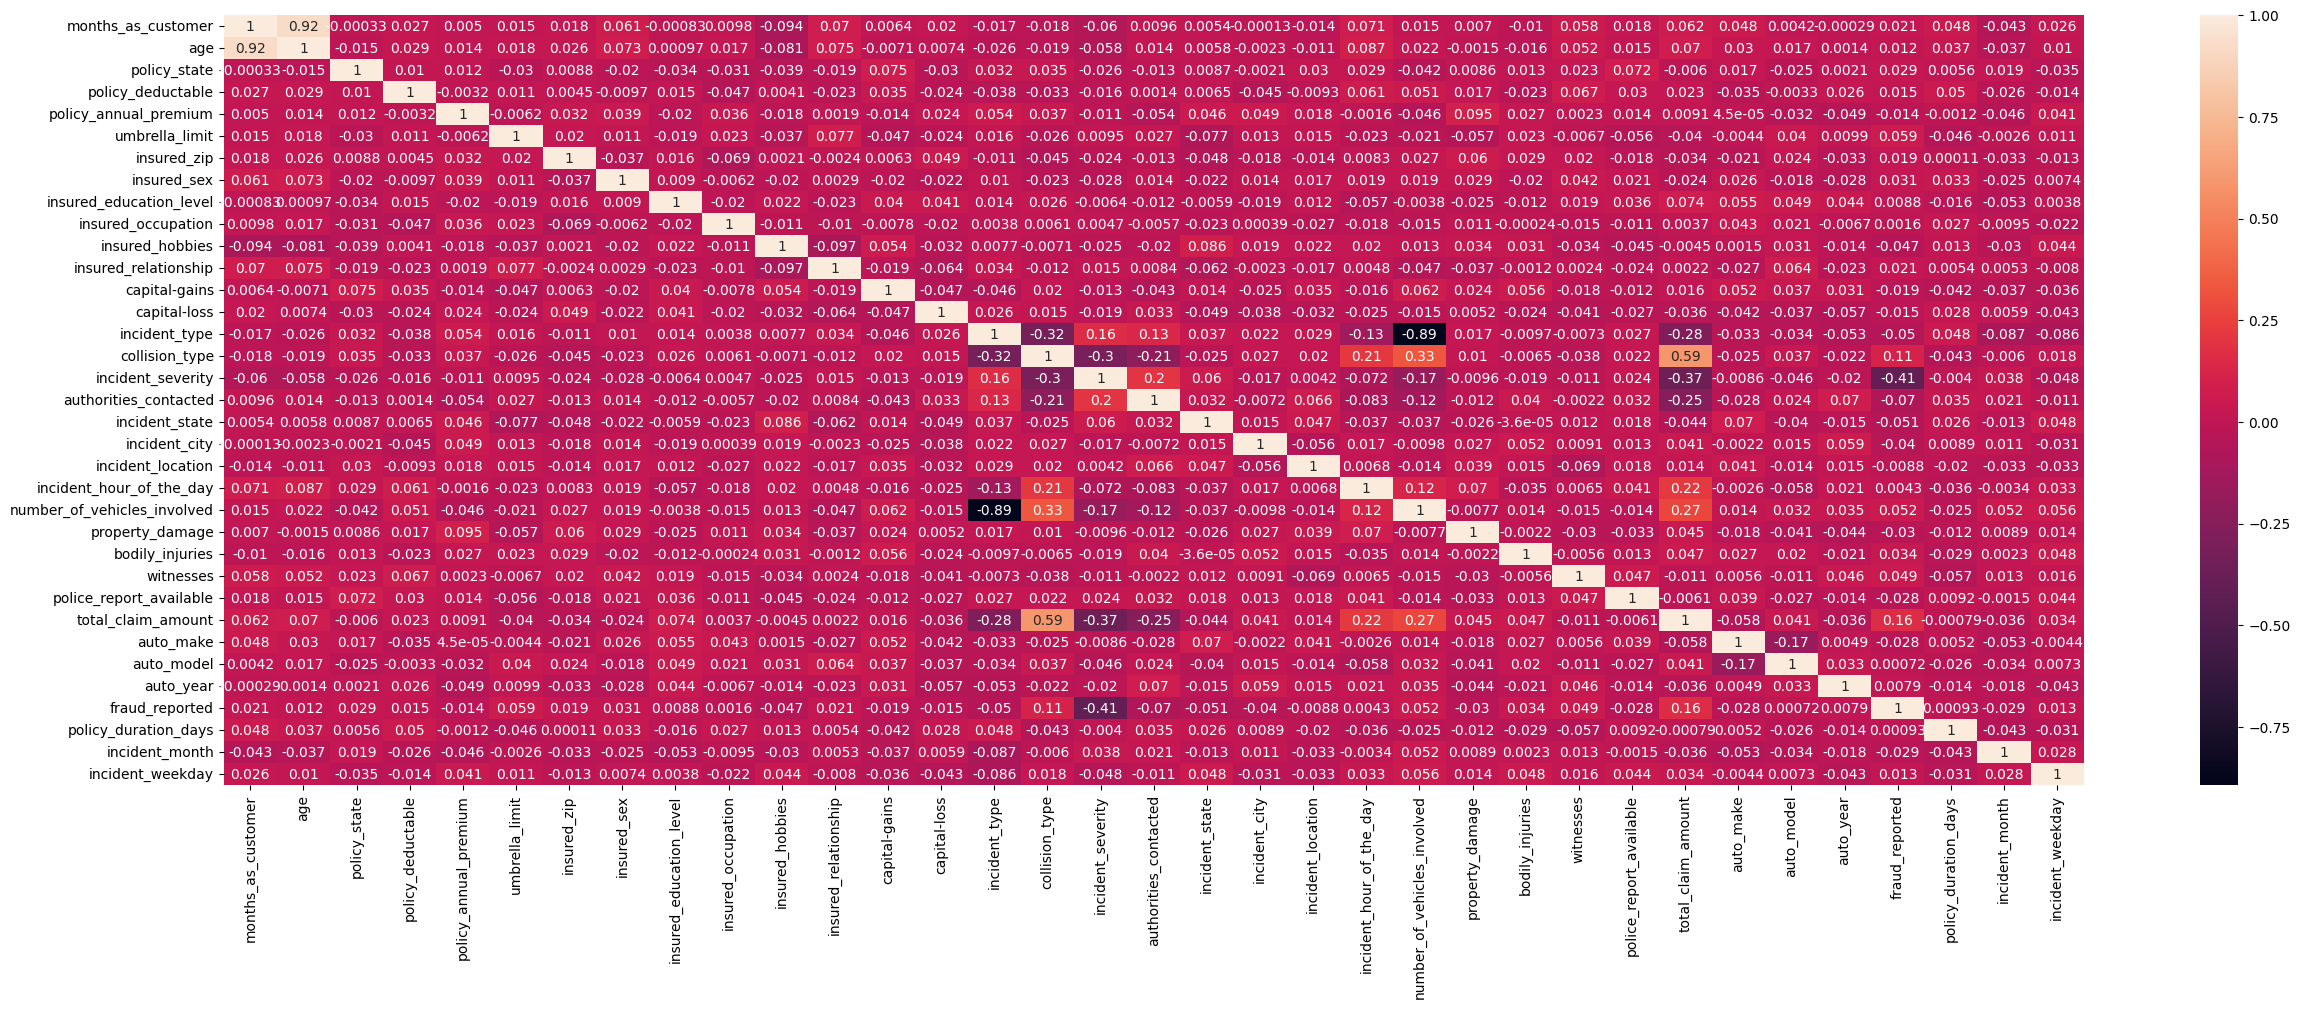

In [922]:
plt.figure(figsize=(30,10))
sns.heatmap(corr_mat, annot= True)
plt.show()

**VIF(Variance Inflation Factor)** It is a feature selection technique which calculates the multicollinearity between columns and drops the column with the highest value

In [923]:
# vif > 5 -high multicollinearity --remove the column

In [924]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

In [925]:
vif_data

,Column Name,VIF Score
0,months_as_customer,28.168186
1,age,130.635992
2,policy_state,2.566495
3,policy_deductable,4.593119
4,policy_annual_premium,28.486216
5,umbrella_limit,1.273420
6,insured_zip,51.332654
7,insured_sex,1.910858
8,insured_education_level,3.434250
9,insured_occupation,3.815375


In [926]:
df.drop('auto_year', axis= 1, inplace= True)

In [927]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,24.620536
1,age,107.176976
2,policy_state,2.544661
3,policy_deductable,4.536384
4,policy_annual_premium,25.939787
5,umbrella_limit,1.272584
6,insured_zip,40.758645
7,insured_sex,1.910123
8,insured_education_level,3.411478
9,insured_occupation,3.743885


In [928]:
df.drop('age', axis= 1, inplace= True)

In [929]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,4.293602
1,policy_state,2.544441
2,policy_deductable,4.520090
3,policy_annual_premium,25.049616
4,umbrella_limit,1.272160
5,insured_zip,37.695127
6,insured_sex,1.903020
7,insured_education_level,3.404340
8,insured_occupation,3.712650
9,insured_hobbies,4.068898


In [930]:
df.drop('policy_annual_premium', axis= 1, inplace= True)

In [931]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,4.287761
1,policy_state,2.539907
2,policy_deductable,4.506768
3,umbrella_limit,1.271991
4,insured_zip,35.007914
5,insured_sex,1.896541
6,insured_education_level,3.403738
7,insured_occupation,3.671662
8,insured_hobbies,4.067212
9,insured_relationship,3.130269


In [932]:
df.drop('insured_zip', inplace= True, axis= 1)

In [933]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,4.251428
1,policy_state,2.523602
2,policy_deductable,4.475708
3,umbrella_limit,1.269029
4,insured_sex,1.896197
5,insured_education_level,3.379480
6,insured_occupation,3.663982
7,insured_hobbies,4.034137
8,insured_relationship,3.106562
9,capital-gains,1.877382


In [934]:
df.drop('number_of_vehicles_involved', axis= 1, inplace= True)

In [935]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,4.206846
1,policy_state,2.519211
2,policy_deductable,4.356685
3,umbrella_limit,1.267840
4,insured_sex,1.873106
5,insured_education_level,3.346162
6,insured_occupation,3.627842
7,insured_hobbies,3.930151
8,insured_relationship,3.089505
9,capital-gains,1.861594


In [936]:
df.drop('total_claim_amount', axis= 1, inplace= True)

In [937]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,4.155831
1,policy_state,2.518829
2,policy_deductable,4.329835
3,umbrella_limit,1.267228
4,insured_sex,1.872857
5,insured_education_level,3.292163
6,insured_occupation,3.619305
7,insured_hobbies,3.926400
8,insured_relationship,3.083325
9,capital-gains,1.861407


In [938]:
# Divide the data into x and y
X = df.drop(columns=['fraud_reported']) # independ feature
y= df['fraud_reported']

In [939]:
X

,months_as_customer,policy_state,policy_deductable,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,...,incident_hour_of_the_day,property_damage,bodily_injuries,witnesses,police_report_available,auto_make,auto_model,policy_duration_days,incident_month,incident_weekday
0,328,2,1000,0,1,4,2,17,0,53300,...,5,2,1,2,2,10,1,100,1,6
1,228,1,2000,5000000,1,4,6,15,2,0,...,8,0,0,0,0,8,12,3130,1,2
2,134,2,2000,5000000,0,6,11,2,3,35100,...,7,1,2,3,1,4,30,5282,2,6
3,256,0,2000,6000000,0,6,1,2,4,48900,...,5,0,1,2,1,3,34,8996,1,5
4,228,0,1000,6000000,1,0,11,2,4,66000,...,20,1,0,1,1,0,31,256,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,2,1000,0,0,5,2,13,4,0,...,20,2,0,1,0,6,6,8622,2,6
996,285,0,1000,0,0,6,9,17,5,70900,...,23,2,2,3,0,13,28,384,1,5
997,130,2,500,3000000,0,5,1,3,2,35100,...,4,0,2,3,2,11,19,4358,1,4
998,458,0,2000,5000000,1,0,5,0,5,0,...,2,0,0,1,2,1,5,1196,2,3


In [940]:
y

0      1
1      1
2      0
3      1
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: fraud_reported, Length: 1000, dtype: int64

In [941]:
X_train , X_test , y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [942]:
model = LogisticRegression()

In [943]:
model.fit(X_train, y_train)

c:\Users\ritik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [944]:
y_pred = model.predict(X_test)

In [945]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

### ***As the predicted results were all of 0, we attempt to use StandardScaler to scale the data***

In [946]:
from sklearn.preprocessing import StandardScaler

In [947]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [948]:
balanced_model = LogisticRegression(class_weight= 'balanced', max_iter= 1000, C=10)
balanced_model.fit(X_train_scaled, y_train)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000)

In [949]:
y_scaled_pred = balanced_model.predict(X_test_scaled)

In [950]:
y_scaled_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1])

In [951]:
# from sklearn.metrics import accuracy_score , precision_score
from sklearn.metrics import*

In [952]:
# check the accuracy of model
accuracy_score(y_test,y_scaled_pred)

0.665

Your matrix looks exactly like this layout:

                        Predicted: NO FRAUD (0)     Predicted: FRAUD (1)
Actual:NO FRAUD (0)       60 (True Negative)         85 (False Positive)

Actual:FRAUD (1)          22 (False Negative)        33 (True Positive)

In [953]:
confusion_matrix(y_test, y_scaled_pred)

array([[95, 50],
       [17, 38]])

In [954]:
recall_score(y_test, y_scaled_pred)

0.6909090909090909

In [955]:
f1_score(y_test, y_scaled_pred)

0.5314685314685315